# Logistic Regression Project (Predict Ad click)

In this notebook we will use `Logistic Regression` to indicating whether or not a particular internet user clicked on an Advertisement. We will try to create a model that will predict whether or not they will click on an ad based off the features of that user.

This data set contains the following features:

* '`Daily Time Spent on Site`': consumer time on site in minutes
* '`Age`': customer age in years
* '`Area Income`': Avg. Income of geographical area of consumer
* '`Daily Internet Usage`': Avg. minutes a day consumer is on the internet
* '`Ad Topic Line`': Headline of the advertisement
* '`City`': City of consumer
* '`Male`': Whether or not consumer was male
* '`Country`': Country of consumer
* '`Timestamp`': Time at which consumer clicked on Ad or closed window
* '`Clicked on Ad`': 0 or 1 indicated clicking on Ad

## Get the Data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv("data/advertising.csv")
df

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,69.80,44,57540.20,192.44,Configurable proactive initiative,City_34,0,Grenada,2016-05-19 09:44:43,0
1,39.95,41,59049.39,181.56,Integrated integrated forecast,City_399,0,San Marino,2016-10-25 21:00:34,1
2,58.06,46,50740.72,162.63,Extended extended policy,City_265,1,Mexico,2016-06-18 08:10:45,1
3,57.97,41,59324.97,140.07,Enhanced reduced functionalities capability,City_385,0,Bolivia,2016-05-10 07:57:13,1
4,76.05,23,64677.42,203.01,Configurable cloned policy,City_478,0,Myanmar,2016-12-13 17:20:39,0
...,...,...,...,...,...,...,...,...,...,...
995,45.01,41,43752.74,177.57,Integrated cloned capability,City_11,0,Qatar,2016-05-30 04:48:12,1
996,66.45,30,59230.41,211.77,Persevering synergistic architecture solution,City_67,1,Germany,2016-10-23 05:25:42,0
997,69.75,36,42954.11,246.04,Synergistic cloned capability,City_445,1,India,2016-10-10 20:14:04,0
998,72.53,47,44167.44,212.20,Configurable extended system capability,City_120,1,Germany,2016-09-13 13:18:46,0


# 1. Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 78.3 KB


In [6]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000
mean,62.249430,36.47100,54113.822260,179.41496,0.461000,0.517000
std,13.272155,8.64615,13116.558271,38.98561,0.498726,0.499961
min,30.480000,19.00000,14890.650000,100.00000,0.000000,0.000000
25%,52.257500,30.00000,44765.780000,148.77500,0.000000,0.000000
50%,61.300000,36.00000,53561.930000,180.76500,0.000000,1.000000
75%,71.460000,42.00000,62575.177500,212.42000,1.000000,1.000000
max,95.000000,61.00000,80000.000000,262.80000,1.000000,1.000000


In [7]:
df['Clicked on Ad'].value_counts()

Clicked on Ad
1    517
0    483
Name: count, dtype: int64

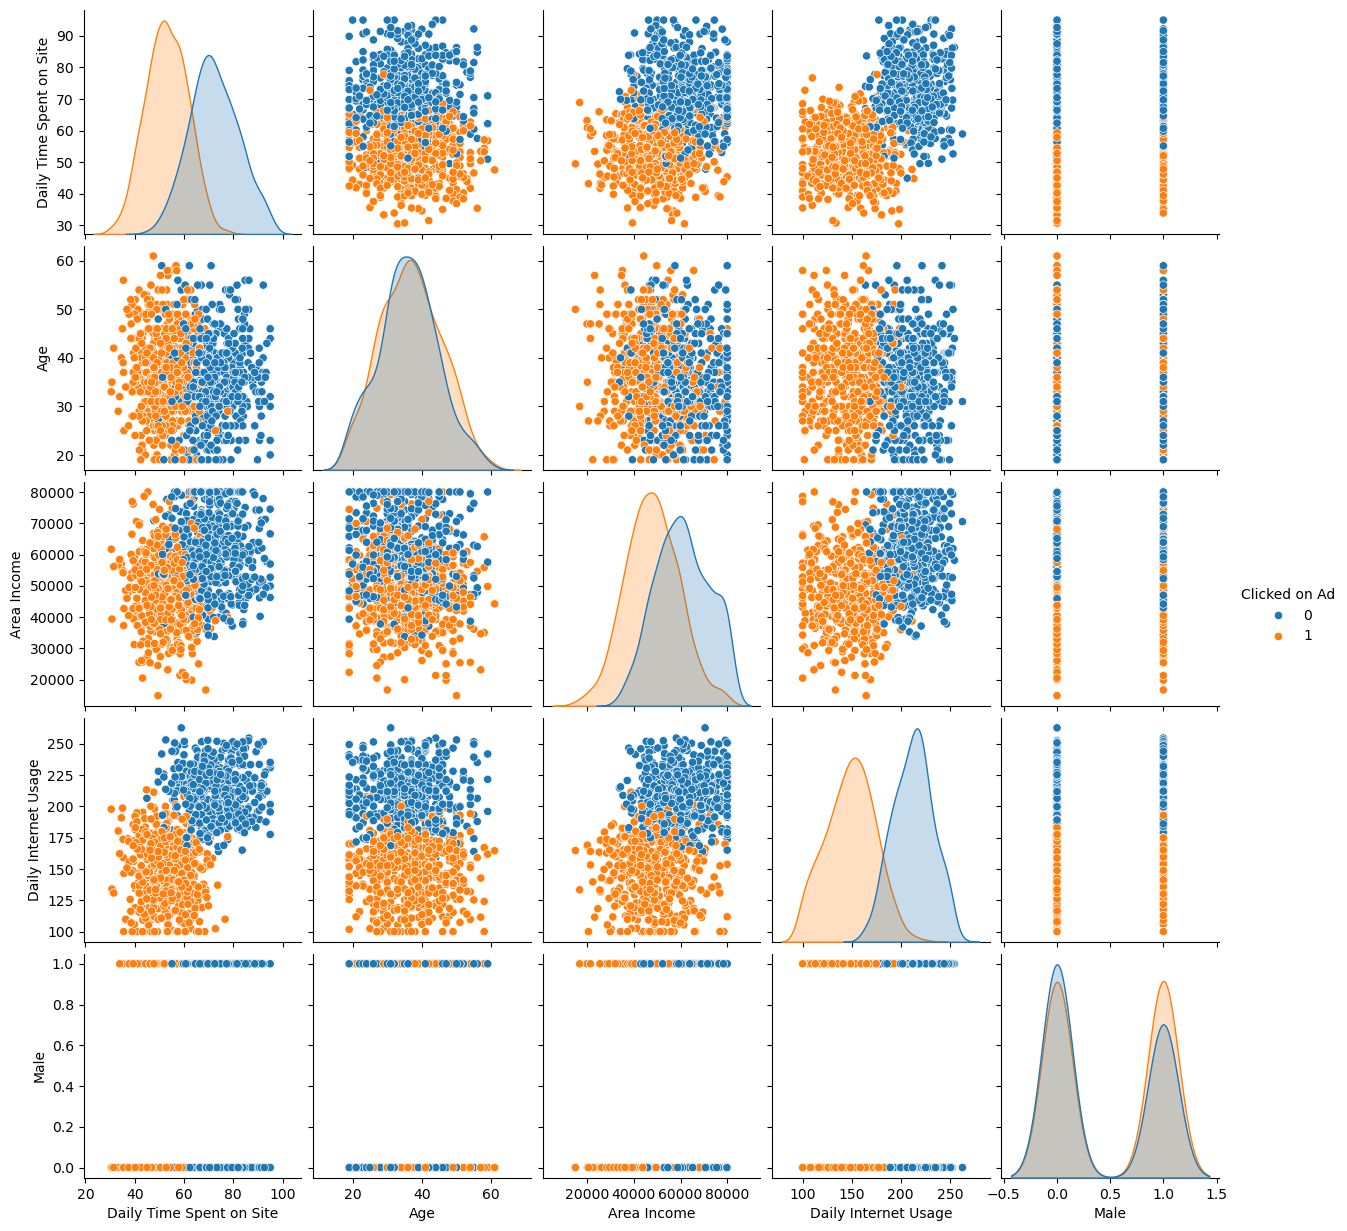

In [8]:
sns.pairplot(df, hue='Clicked on Ad')

<Axes: >

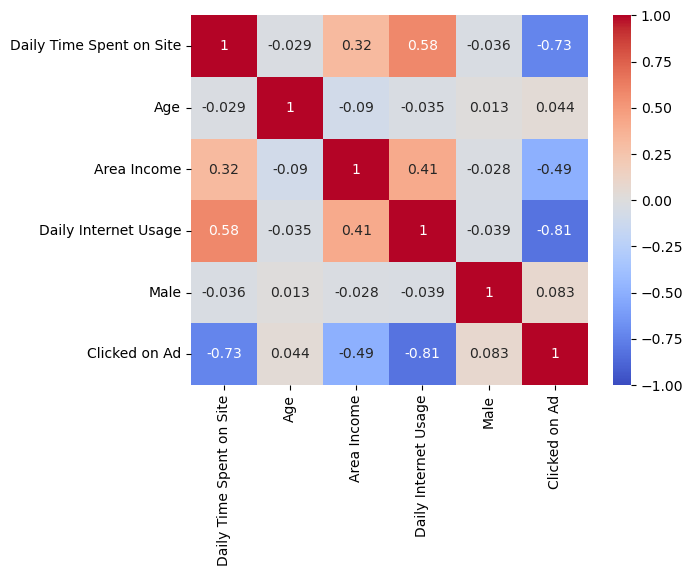

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1)

# 2. Prepare Data for Logistic Regression



#### 1. Feature engineering


In [10]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,69.80,44,57540.20,192.44,Configurable proactive initiative,City_34,0,Grenada,2016-05-19 09:44:43,0
1,39.95,41,59049.39,181.56,Integrated integrated forecast,City_399,0,San Marino,2016-10-25 21:00:34,1
2,58.06,46,50740.72,162.63,Extended extended policy,City_265,1,Mexico,2016-06-18 08:10:45,1
3,57.97,41,59324.97,140.07,Enhanced reduced functionalities capability,City_385,0,Bolivia,2016-05-10 07:57:13,1
4,76.05,23,64677.42,203.01,Configurable cloned policy,City_478,0,Myanmar,2016-12-13 17:20:39,0


In [11]:
df['Ad Topic Line'].nunique()

906

In [12]:
df['Ad Topic Line'].str.split(" ")

0                  [Configurable, proactive, initiative]
1                     [Integrated, integrated, forecast]
2                           [Extended, extended, policy]
3       [Enhanced, reduced, functionalities, capability]
4                         [Configurable, cloned, policy]
                             ...                        
995                     [Integrated, cloned, capability]
996    [Persevering, synergistic, architecture, , sol...
997                    [Synergistic, cloned, capability]
998         [Configurable, extended, system, capability]
999    [Configurable, synergistic, solution, capability]
Name: Ad Topic Line, Length: 1000, dtype: object

In [13]:
lista_palabras = []
for topic in df['Ad Topic Line']:
    for palabra in topic.split(" "):
        lista_palabras.append(palabra.lower())

In [14]:
pd.Series(lista_palabras).value_counts()

capability         287
solution           261
system             229
universal          220
synergistic        220
configurable       214
integrated         208
cloned             205
proactive          201
reduced            192
extended           191
enhanced           184
                   181
persevering        165
architecture        73
protocol            68
methodology         67
initiative          65
productivity        64
infrastructure      63
paradigm            63
forecast            58
policy              58
analyzer            58
functionalities     55
framework           54
emulation           53
Name: count, dtype: int64

In [15]:
df['Topic_solution'] = np.where(df['Ad Topic Line'].str.contains("solution"), 1, 0)
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Topic_solution
0,69.80,44,57540.20,192.44,Configurable proactive initiative,City_34,0,Grenada,2016-05-19 09:44:43,0,0
1,39.95,41,59049.39,181.56,Integrated integrated forecast,City_399,0,San Marino,2016-10-25 21:00:34,1,0
2,58.06,46,50740.72,162.63,Extended extended policy,City_265,1,Mexico,2016-06-18 08:10:45,1,0
3,57.97,41,59324.97,140.07,Enhanced reduced functionalities capability,City_385,0,Bolivia,2016-05-10 07:57:13,1,0
4,76.05,23,64677.42,203.01,Configurable cloned policy,City_478,0,Myanmar,2016-12-13 17:20:39,0,0


In [16]:
df['Topic_solution'].value_counts()

Topic_solution
0    748
1    252
Name: count, dtype: int64

In [17]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [18]:
df['City_encoded'] = encoder.fit_transform(df['City'])
df

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Topic_solution,City_encoded
0,69.80,44,57540.20,192.44,Configurable proactive initiative,City_34,0,Grenada,2016-05-19 09:44:43,0,0,268
1,39.95,41,59049.39,181.56,Integrated integrated forecast,City_399,0,San Marino,2016-10-25 21:00:34,1,0,333
2,58.06,46,50740.72,162.63,Extended extended policy,City_265,1,Mexico,2016-06-18 08:10:45,1,0,185
3,57.97,41,59324.97,140.07,Enhanced reduced functionalities capability,City_385,0,Bolivia,2016-05-10 07:57:13,1,0,318
4,76.05,23,64677.42,203.01,Configurable cloned policy,City_478,0,Myanmar,2016-12-13 17:20:39,0,0,421
...,...,...,...,...,...,...,...,...,...,...,...,...
995,45.01,41,43752.74,177.57,Integrated cloned capability,City_11,0,Qatar,2016-05-30 04:48:12,1,0,13
996,66.45,30,59230.41,211.77,Persevering synergistic architecture solution,City_67,1,Germany,2016-10-23 05:25:42,0,1,464
997,69.75,36,42954.11,246.04,Synergistic cloned capability,City_445,1,India,2016-10-10 20:14:04,0,0,385
998,72.53,47,44167.44,212.20,Configurable extended system capability,City_120,1,Germany,2016-09-13 13:18:46,0,0,25


In [19]:
df['City_encoded'].nunique()/len(df)

0.5

### OneHotEncoding

In [20]:
pd.get_dummies(df['Country'])

,Argentina,Australia,Bolivia,Brazil,Burundi,Canada,China,Czech Republic,Egypt,France,...,Nauru,Norway,Peru,Poland,Qatar,Russia,San Marino,Spain,Tunisia,Turkey
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [21]:
encoder = LabelEncoder()
df['Country_encoded'] = encoder.fit_transform(df['Country'])
df

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Topic_solution,City_encoded,Country_encoded
0,69.80,44,57540.20,192.44,Configurable proactive initiative,City_34,0,Grenada,2016-05-19 09:44:43,0,0,268,12
1,39.95,41,59049.39,181.56,Integrated integrated forecast,City_399,0,San Marino,2016-10-25 21:00:34,1,0,333,26
2,58.06,46,50740.72,162.63,Extended extended policy,City_265,1,Mexico,2016-06-18 08:10:45,1,0,185,18
3,57.97,41,59324.97,140.07,Enhanced reduced functionalities capability,City_385,0,Bolivia,2016-05-10 07:57:13,1,0,318,2
4,76.05,23,64677.42,203.01,Configurable cloned policy,City_478,0,Myanmar,2016-12-13 17:20:39,0,0,421,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,45.01,41,43752.74,177.57,Integrated cloned capability,City_11,0,Qatar,2016-05-30 04:48:12,1,0,13,24
996,66.45,30,59230.41,211.77,Persevering synergistic architecture solution,City_67,1,Germany,2016-10-23 05:25:42,0,1,464,10
997,69.75,36,42954.11,246.04,Synergistic cloned capability,City_445,1,India,2016-10-10 20:14:04,0,0,385,14
998,72.53,47,44167.44,212.20,Configurable extended system capability,City_120,1,Germany,2016-09-13 13:18:46,0,0,25,10


In [22]:
df['Country'].nunique()

30

In [23]:
df.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad', 'Topic_solution', 'City_encoded',
       'Country_encoded'],
      dtype='str')

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
 10  Topic_solution            1000 non-null   int64  
 11  City_encoded              1000 non-null   int64  
 12  Country_encoded           1000 non-null   int64  
dtypes: float64(3), int64(6), str(4)
memory usage: 101.7 KB


In [25]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [26]:
df['month'] = df['Timestamp'].dt.month
df['month_dau'] = df['Timestamp'].dt.day
df['week_day'] = df['Timestamp'].dt.weekday
df['hour'] = df['Timestamp'].dt.hour
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,Topic_solution,City_encoded,Country_encoded,month,month_dau,week_day,hour
0,69.80,44,57540.20,192.44,Configurable proactive initiative,City_34,0,Grenada,2016-05-19 09:44:43,0,0,268,12,5,19,3,9
1,39.95,41,59049.39,181.56,Integrated integrated forecast,City_399,0,San Marino,2016-10-25 21:00:34,1,0,333,26,10,25,1,21
2,58.06,46,50740.72,162.63,Extended extended policy,City_265,1,Mexico,2016-06-18 08:10:45,1,0,185,18,6,18,5,8
3,57.97,41,59324.97,140.07,Enhanced reduced functionalities capability,City_385,0,Bolivia,2016-05-10 07:57:13,1,0,318,2,5,10,1,7
4,76.05,23,64677.42,203.01,Configurable cloned policy,City_478,0,Myanmar,2016-12-13 17:20:39,0,0,421,19,12,13,1,17


In [27]:
df.groupby('Topic_solution')['Clicked on Ad'].mean()

Topic_solution
0    0.526738
1    0.488095
Name: Clicked on Ad, dtype: float64

In [28]:
df.groupby('Topic_solution')['Clicked on Ad'].value_counts()

Topic_solution  Clicked on Ad
0               1                394
                0                354
1               0                129
                1                123
Name: count, dtype: int64

In [29]:
df.groupby('month')['Clicked on Ad'].mean()

month
1     0.539326
2     0.583333
3     0.530120
4     0.558442
5     0.397727
6     0.529412
7     0.443182
8     0.552083
9     0.549296
10    0.487500
11    0.493976
12    0.543210
Name: Clicked on Ad, dtype: float64

In [30]:
df.groupby('hour')['Clicked on Ad'].mean()

hour
0     0.536585
1     0.586957
2     0.634615
3     0.583333
4     0.628571
5     0.515152
6     0.630435
7     0.486486
8     0.625000
9     0.448980
10    0.552632
11    0.416667
12    0.536585
13    0.571429
14    0.400000
15    0.545455
16    0.600000
17    0.431373
18    0.425000
19    0.473684
20    0.460000
21    0.594595
22    0.382353
23    0.317073
Name: Clicked on Ad, dtype: float64

In [31]:
df.groupby('hour')['Clicked on Ad'].value_counts(normalize=True)

hour  Clicked on Ad
0     1                0.536585
      0                0.463415
1     1                0.586957
      0                0.413043
2     1                0.634615
      0                0.365385
3     1                0.583333
      0                0.416667
4     1                0.628571
      0                0.371429
5     1                0.515152
      0                0.484848
6     1                0.630435
      0                0.369565
7     0                0.513514
      1                0.486486
8     1                0.625000
      0                0.375000
9     0                0.551020
      1                0.448980
10    1                0.552632
      0                0.447368
11    0                0.583333
      1                0.416667
12    1                0.536585
      0                0.463415
13    1                0.571429
      0                0.428571
14    0                0.600000
      1                0.400000
15    1             

In [32]:
df.groupby('month_dau')['Clicked on Ad'].mean()

month_dau
1     0.500000
2     0.516129
3     0.517241
4     0.447368
5     0.382353
6     0.500000
7     0.531250
8     0.428571
9     0.641026
10    0.472222
11    0.571429
12    0.558824
13    0.512821
14    0.454545
15    0.515152
16    0.384615
17    0.547619
18    0.428571
19    0.566667
20    0.600000
21    0.500000
22    0.676471
23    0.419355
24    0.566667
25    0.382353
26    0.612903
27    0.419355
28    0.517241
29    0.540541
30    0.648649
31    0.631579
Name: Clicked on Ad, dtype: float64

In [33]:
df.groupby('week_day')['Clicked on Ad'].mean()

week_day
0    0.555556
1    0.536424
2    0.493333
3    0.493243
4    0.548872
5    0.541353
6    0.460000
Name: Clicked on Ad, dtype: float64

<Axes: >

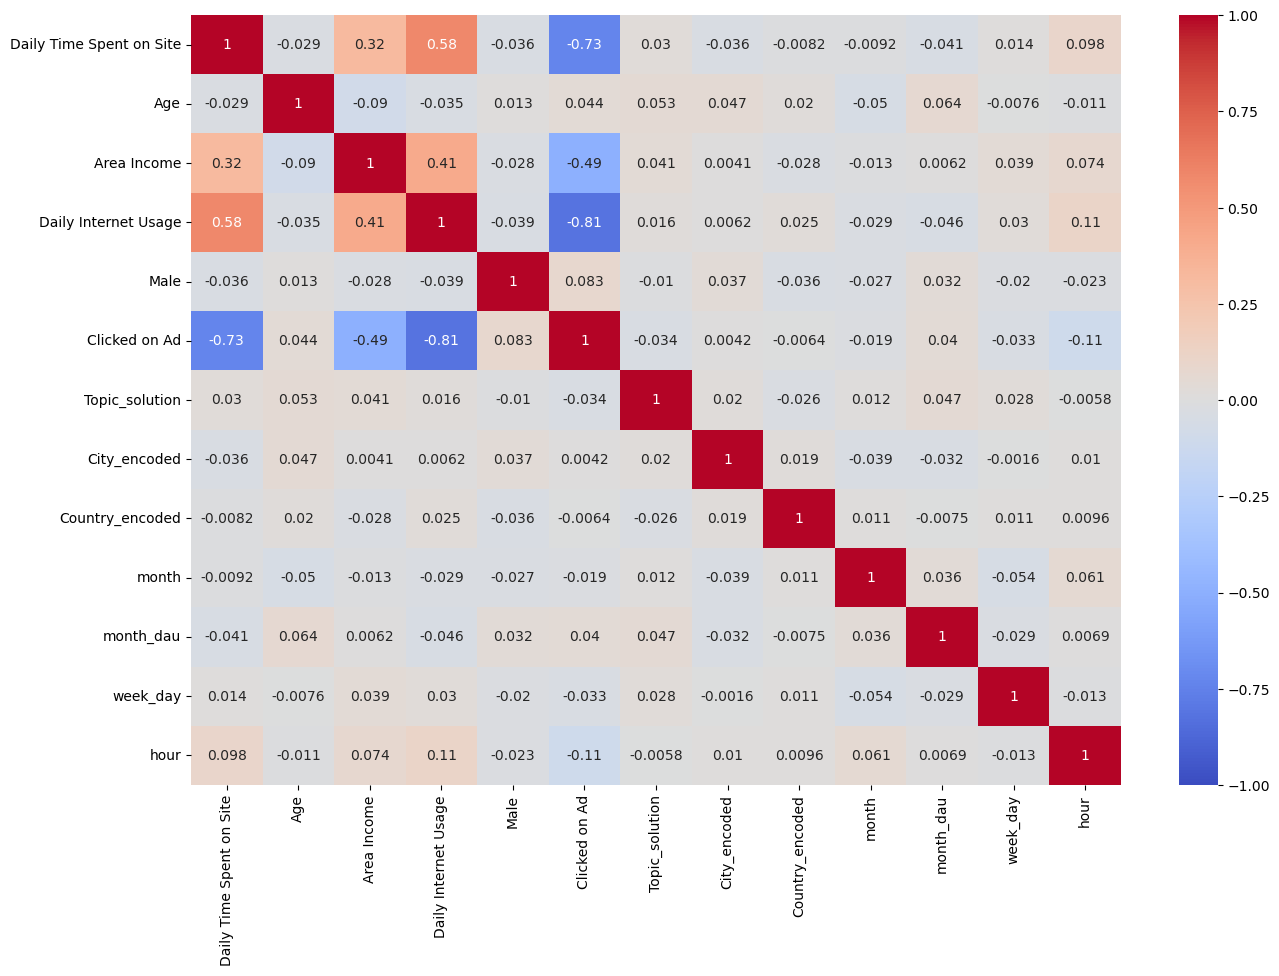

In [34]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1)


#### 2. Train test split


In [35]:
df.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad', 'Topic_solution', 'City_encoded',
       'Country_encoded', 'month', 'month_dau', 'week_day', 'hour'],
      dtype='str')

In [36]:
X = df[['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Male', 'Topic_solution', 'month',
       'month_dau', 'week_day', 'hour']]
# X = df[['Daily Time Spent on Site','Daily Internet Usage']]
y = df['Clicked on Ad']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 10)
(200, 10)
(800,)
(200,)


<Axes: >

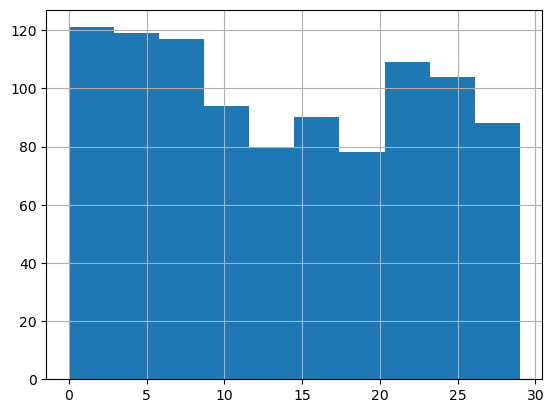

In [39]:
df['Country_encoded'].hist()


#### 3. StandardScaler()


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

In [41]:
scaler.inverse_transform(X_test_scal)

array([[6.188000e+01, 3.100000e+01, 5.993843e+04, ..., 3.100000e+01,
        3.000000e+00, 0.000000e+00],
       [6.046000e+01, 5.500000e+01, 5.248672e+04, ..., 5.000000e+00,
        1.000000e+00, 2.200000e+01],
       [5.503000e+01, 4.200000e+01, 4.560812e+04, ..., 7.000000e+00,
        0.000000e+00, 1.100000e+01],
       ...,
       [5.166000e+01, 3.700000e+01, 6.123480e+04, ..., 9.000000e+00,
        0.000000e+00, 7.000000e+00],
       [5.820000e+01, 3.000000e+01, 5.536349e+04, ..., 2.100000e+01,
        1.000000e+00, 1.400000e+01],
       [6.600000e+01, 2.800000e+01, 6.235461e+04, ..., 2.500000e+01,
        3.000000e+00, 1.400000e+01]], shape=(200, 10))

# 3. Implement a Logistic Regression in Scikit-Learn and predict. Use cross validation.

### 3.1 Entrenamos la regresión logística
Usamos los datos ESCALADOS (`X_train_scal`), no los originales. Es importante porque la logística de sklearn aplica regularización por defecto, y la regularización necesita features escaladas para no castigar injustamente a las que tengan unidades grandes.

In [42]:
from sklearn.linear_model import LogisticRegression

# Creamos el modelo. max_iter=1000 para asegurar que el Gradient Descent
# tiene iteraciones de sobra para converger (con 100 por defecto a veces
# salta un warning de no convergencia).
modelo = LogisticRegression(max_iter=1000)

# Entrenamos con los datos escalados de train
modelo.fit(X_train_scal, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 3.2 Hacemos predicciones
`predict` nos da directamente la clase 0 o 1 aplicando el umbral por defecto (0.5) sobre la probabilidad.

`predict_proba` nos devuelve las probabilidades de cada clase. La columna `[:, 1]` es la probabilidad de clase 1 (hizo clic), que nos hará falta más adelante para la ROC y la P-R curve.

In [43]:
# Predicción de clase (0 o 1) sobre el test
y_pred = modelo.predict(X_test_scal)

# Probabilidades de pertenecer a la clase 1 (hizo clic)
y_pred_proba = modelo.predict_proba(X_test_scal)[:, 1]

# Echamos un ojo a las primeras predicciones vs reales
print("Predicciones:", y_pred[:10])
print("Reales:      ", y_test.values[:10])
print("Probas:      ", y_pred_proba[:10].round(3))

Predicciones: [0 1 1 1 1 0 0 1 1 1]
Reales:       [0 0 1 1 1 0 0 1 1 1]
Probas:       [0.431 0.864 0.999 0.995 1.    0.001 0.001 1.    1.    1.   ]


### 3.3 Accuracy en train y test
Una primera mirada rápida para ver si hay overfitting: si el accuracy en train es mucho mayor que en test, tendríamos problema. Si son parecidos, el modelo generaliza bien.

In [44]:
print(f"Accuracy en train: {modelo.score(X_train_scal, y_train):.4f}")
print(f"Accuracy en test:  {modelo.score(X_test_scal, y_test):.4f}")

Accuracy en train: 0.9738
Accuracy en test:  0.9750


### 3.4 Validación cruzada
Con un solo split train/test la métrica puede salir alta o baja por azar. Con `cross_val_score` hacemos CV de 5 pliegues sobre el train para tener una estimación más robusta y ver la estabilidad del modelo (desviación típica baja = modelo estable).

Importante: hacemos CV solo sobre train. El test lo reservamos para la evaluación final.

In [45]:
from sklearn.model_selection import cross_val_score

# 5 pliegues sobre el train escalado. Métrica: accuracy (las clases están
# balanceadas en este dataset, así que accuracy es una métrica razonable aquí).
cv_scores = cross_val_score(modelo, X_train_scal, y_train, cv=5, scoring='accuracy')

print("Accuracy por pliegue:", cv_scores.round(4))
print(f"Media:     {cv_scores.mean():.4f}")
print(f"Std:       {cv_scores.std():.4f}")

Accuracy por pliegue: [0.975  0.9625 0.9688 0.9812 0.9625]
Media:     0.9700
Std:       0.0073


### 3.5 Coeficientes del modelo
Como hemos escalado los datos, los coeficientes son directamente comparables entre sí: el que tenga mayor valor absoluto es la feature más influyente. Así conseguimos un ranking de feature importance.

In [46]:
# Emparejamos cada coeficiente con su nombre de feature
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coef': modelo.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

coefs

,feature,coef
3,Daily Internet Usage,-3.797922
0,Daily Time Spent on Site,-2.514668
2,Area Income,-0.849190
4,Male,0.340924
6,month,-0.236313
5,Topic_solution,-0.146760
9,hour,-0.143051
1,Age,0.114206
7,month_dau,-0.063932
8,week_day,-0.033211


# 4. Evaluation


In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report


#### 1. Confusion Matrix


In [48]:
# confusion_matrix devuelve una matriz 2x2 con el siguiente orden:
#   [[TN, FP],
#    [FN, TP]]
# donde la fila es lo que era en realidad y la columna lo que predijo el modelo.
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[101   3]
 [  2  94]]


In [49]:
# Extraemos las 4 casillas para comentarlas
tn, fp, fn, tp = cm.ravel()
print(f"TN (acertó 0): {tn}")
print(f"FP (falsa alarma): {fp}")
print(f"FN (se escapó 1): {fn}")
print(f"TP (acertó 1): {tp}")

TN (acertó 0): 101
FP (falsa alarma): 3
FN (se escapó 1): 2
TP (acertó 1): 94


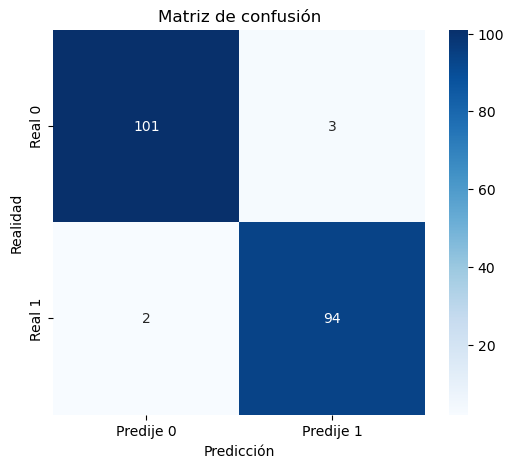

In [50]:
# Visualizamos la matriz como heatmap para que se lea mejor
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predije 0', 'Predije 1'],
            yticklabels=['Real 0', 'Real 1'])
plt.title('Matriz de confusión')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()


#### 2. Precision


In [51]:
# Precision = TP / (TP + FP)
# Responde: de los que predije como 1, ¿cuántos realmente eran 1?
# Cuanto más alta, menos falsos positivos comete el modelo.
prec = precision_score(y_test, y_pred)
print(f"Precision: {prec:.4f}")

# Comprobación manual con las casillas de la matriz
print(f"Manual: TP / (TP + FP) = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")

Precision: 0.9691
Manual: TP / (TP + FP) = 94 / (94 + 3) = 0.9691




#### 3. Recall


In [52]:
# Recall = TP / (TP + FN)
# Responde: de los 1s que había en realidad, ¿a cuántos pilló el modelo?
# Cuanto más alta, menos positivos se le escapan (menos falsos negativos).
rec = recall_score(y_test, y_pred)
print(f"Recall: {rec:.4f}")

# Comprobación manual
print(f"Manual: TP / (TP + FN) = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")

Recall: 0.9792
Manual: TP / (TP + FN) = 94 / (94 + 2) = 0.9792




#### 4. F1 Score


In [53]:
# F1 = 2 * (precision * recall) / (precision + recall)
# Media armónica de precision y recall. Es alta solo cuando AMBAS son altas:
# si una de las dos es baja, el F1 se hunde. Útil cuando queremos un único
# número que combine los dos criterios.
f1 = f1_score(y_test, y_pred)
print(f"F1: {f1:.4f}")

# Manual
f1_manual = 2 * (prec * rec) / (prec + rec)
print(f"Manual: 2 * (prec * rec) / (prec + rec) = {f1_manual:.4f}")

F1: 0.9741
Manual: 2 * (prec * rec) / (prec + rec) = 0.9741


También podemos imprimir el `classification_report`, que nos da precision, recall y F1 para las dos clases de una tacada. Es lo estándar para reportar un modelo de clasificación.

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       104
           1       0.97      0.98      0.97        96

    accuracy                           0.97       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.97      0.98       200





#### 5. ROC curve

La curva ROC pinta el TPR (recall) contra el FPR para distintos umbrales. El AUC mide el área bajo la curva: cuanto más cercano a 1, mejor discrimina el modelo entre las dos clases.

In [55]:
from sklearn.metrics import roc_curve, auc

# roc_curve nos da los puntos (fpr, tpr) barriendo todos los umbrales.
# Usamos y_pred_proba (probabilidades), NO y_pred (clases),
# porque la ROC necesita evaluar el modelo en muchos umbrales distintos.
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# El AUC (Area Under Curve) resume la curva en un solo número entre 0 y 1.
auc_val = auc(fpr, tpr)
print(f"AUC: {auc_val:.4f}")

AUC: 0.9974


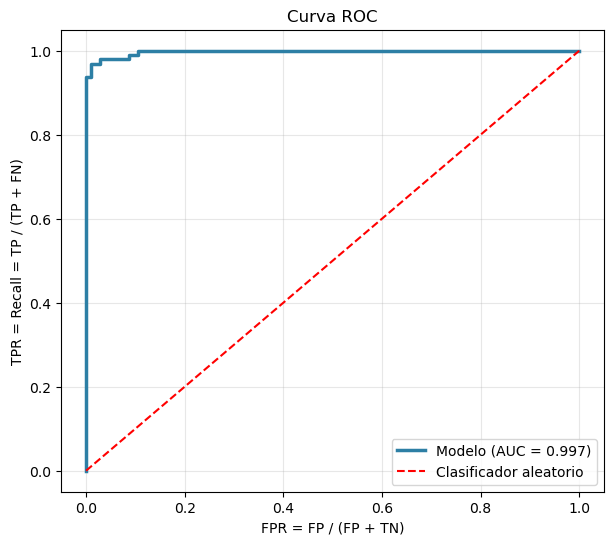

In [56]:
# Dibujamos la curva
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2d7fa5', linewidth=2.5,
         label=f'Modelo (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red',
         label='Clasificador aleatorio')
plt.xlabel('FPR = FP / (FP + TN)')
plt.ylabel('TPR = Recall = TP / (TP + FN)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()



#### 6. P-R curve

La P-R curve muestra precision vs recall para distintos umbrales. Es especialmente útil cuando las clases están desbalanceadas, porque la ROC puede ser optimista en esos casos. Aquí las clases están balanceadas, así que nos sale parecida a la ROC, pero el concepto es distinto.

In [57]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# precision_recall_curve devuelve precision, recall y los umbrales
precisions, recalls, thr_pr = precision_recall_curve(y_test, y_pred_proba)

# Average Precision (AP) resume la P-R curve en un solo número
ap = average_precision_score(y_test, y_pred_proba)
print(f"Average Precision: {ap:.4f}")

Average Precision: 0.9974


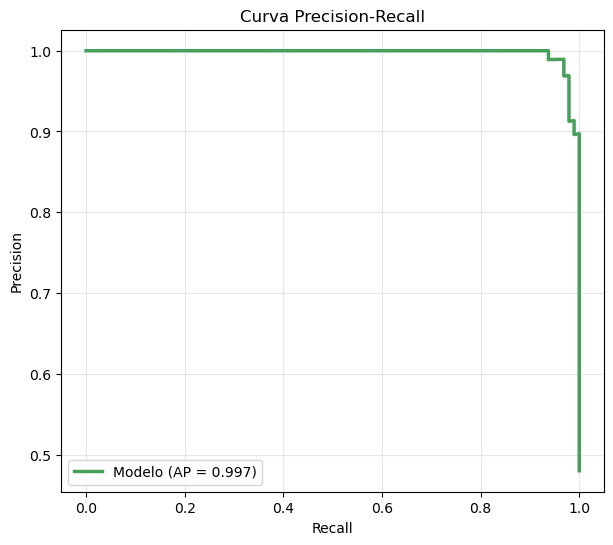

In [58]:
# Dibujamos
plt.figure(figsize=(7, 6))
plt.plot(recalls, precisions, color='#4a9e5c', linewidth=2.5,
         label=f'Modelo (AP = {ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

### Conclusión del análisis
El modelo alcanza un rendimiento muy alto en todas las métricas. En este problema las clases están equilibradas (aprox. 50/50), así que accuracy ya es una métrica fiable. Las features más influyentes tras el escalado son el tiempo en sitio y el uso de internet diario: ambos con coeficiente negativo, lo que encaja con la intuición de que los usuarios que hacen clic son precisamente los que menos tiempo pasan online (probablemente un perfil más ligero de uso, más susceptible al anuncio).